In [65]:
#1.Imports
# numpy: operaciones numéricas eficientes (arrays, logaritmos, medias, etc.)
import numpy as np

# pandas: manipulación de datos tabulares (DataFrames)
import pandas as pd

# GEOparse: descarga y lectura de datasets del repositorio GEO
# nos permite acceder directamente a datasets de expresión génica
import GEOparse

# matplotlib: generación de gráficos
import matplotlib.pyplot as plt

# Pipeline: permite encadenar pasos (preprocesado + modelo)
# clave para evitar data leakage dentro de validación cruzada
from sklearn.pipeline import Pipeline

# StandardScaler: normaliza variables (media=0, var=1)
# necesario para modelos sensibles a escala (SVM, regresión)
from sklearn.preprocessing import StandardScaler

# VarianceThreshold: elimina variables con poca variabilidad
# útil para quitar genes irrelevantes
# SelectKBest: selecciona las K mejores variables según un criterio
# f_classif: ANOVA, mide relación entre variable y clase
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# StratifiedKFold: validación cruzada manteniendo proporción de clases
# cross_validate: ejecuta CV y devuelve métricas
from sklearn.model_selection import StratifiedKFold, cross_validate

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression  # modelo lineal interpretable
from sklearn.svm import SVC                           # SVM (potente en alta dimensión)
from sklearn.ensemble import RandomForestClassifier   # modelo robusto basado en árboles

import time
import winsound  # solo Windows

In [75]:
#2. CONFIGURACIÓN

# Fijamos semilla para reproducibilidad
# esto asegura que los resultados sean replicables
RANDOM_STATE = 42

# Número de variables (genes) que se seleccionarán
# hiperparámetro importante que controla complejidad del modelo
K_VALUES = [20, 50, 100, 500, 1000]

In [67]:
#3. Dataset
# Descargamos el dataset GSE2034 desde GEO
# si ya está descargado, se reutiliza (no descarga otra vez)
gse = GEOparse.get_GEO("GSE2034", destdir="../data")

25-Mar-2026 15:26:38 DEBUG utils - Directory ../data already exists. Skipping.
25-Mar-2026 15:26:38 INFO GEOparse - File already exist: using local version.
25-Mar-2026 15:26:38 INFO GEOparse - Parsing ../data\GSE2034_family.soft.gz: 
25-Mar-2026 15:26:38 DEBUG GEOparse - DATABASE: GeoMiame
25-Mar-2026 15:26:38 DEBUG GEOparse - SERIES: GSE2034
25-Mar-2026 15:26:39 DEBUG GEOparse - PLATFORM: GPL96
25-Mar-2026 15:26:39 DEBUG GEOparse - SAMPLE: GSM36777
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36778
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36779
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36780
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36781
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36782
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36783
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36784
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36785
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM36786
25-Mar-2026 15:26:40 DEBUG GEOparse - SAMPLE: GSM3

In [76]:
#4. Matriz de Expresión (X)
# Creamos un diccionario donde:
# clave = muestra (paciente)
# valor = vector de expresión génica
expr_data = {}

# Iteramos sobre todas las muestras del dataset
for gsm_name, gsm in gse.gsms.items():
    
    # gsm.table contiene los datos del microarray
    # ID_REF = identificador del gen/probe
    # VALUE = nivel de expresión
    
    # Convertimos la tabla en un vector indexado por genes
    expr_data[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

# Convertimos el diccionario en DataFrame
# filas = muestras, columnas = genes
X = pd.DataFrame(expr_data).T

print("Shape X:", X.shape)

Shape X: (286, 22283)


In [77]:
#5. EXTRACCIÓN DE LABELS
# Lista donde guardaremos la variable objetivo (metástasis sí/no)
y = []

# Iteramos sobre cada muestra
for gsm_name, gsm in gse.gsms.items():
    
    # Obtenemos metadatos clínicos
    chars = gsm.metadata.get("characteristics_ch1", [])
    
    label = None
    
    # Buscamos el campo relevante
    for c in chars:
        c = c.lower()
        
        # Este dataset codifica la variable así:
        # "bone relapses (1=yes, 0=no): X"
        if "bone relapses" in c:
            
            # Extraemos el valor numérico (0 o 1)
            label = int(c.split(":")[-1].strip())
    
    # Si no encontramos etiqueta → error
    if label is None:
        raise ValueError(f"No se pudo extraer label para {gsm_name}")
    
    y.append(label)

# Convertimos a array numpy
y = np.array(y)

# Comprobamos distribución de clases
# importante para detectar errores en etiquetas
print("Distribución de clases:", np.bincount(y))

# Verificación de que hay exactamente dos clases
assert len(np.unique(y)) == 2, "Error: solo hay una clase"

Distribución de clases: [217  69]


In [78]:
#6. Transformación Logaritmica
# Aplicamos log2(x + 1)
# motivo:
# - los datos de microarray son altamente asimétricos
# - el log estabiliza la varianza y mejora modelos
X_log = np.log2(X + 1)

In [79]:
#7. Pipelines
# Definimos varios pipelines para comparar modelos
# cada pipeline incluye:
# preprocesado + selección + modelo

pipelines = {

    # Modelo baseline SIN selección de características
    # sirve como referencia para evaluar si la selección mejora resultados
    "LR baseline": Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),  # elimina genes poco variables
        ("scaler", StandardScaler()),                     # normaliza datos
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    # Logistic Regression + selección ANOVA
    "LR + SelectKBest": Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=K)),  # selecciona K mejores genes
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),

    # SVM con kernel RBF + selección
    "SVM (RBF) + SelectKBest": Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=K)),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),

    # Random Forest + selección
    # no usamos scaler porque RF no depende de la escala
    "RF + SelectKBest": Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("select", SelectKBest(score_func=f_classif, k=K)),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ))
    ])
}

In [73]:
# 8. VALIDACIÓN CRUZADA (EXPERIMENTO CON DISTINTOS K)
import time
from sklearn.feature_selection import mutual_info_classif, RFE

# Guardamos tiempo total del experimento
total_start = time.time()

# Validación cruzada estratificada (mantiene proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Lista donde guardaremos TODOS los resultados
all_results = []

# Loop sobre distintos valores de K (número de genes seleccionados)
for K in K_VALUES:

    print(f"\nEvaluando K = {K}")

    # Definimos pipelines dentro del loop (IMPORTANTE: K cambia)
    pipelines = {

        # --------------------------------------------------
        # BASELINE (sin selección de variables)
        # --------------------------------------------------
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),  # elimina genes poco variables
            ("scaler", StandardScaler()),                     # normaliza datos
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # ANOVA (selección univariante)
        # --------------------------------------------------
        "LR + ANOVA": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),  # selecciona K mejores genes
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # MUTUAL INFORMATION (no lineal)
        # --------------------------------------------------
        "LR + MutualInfo": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(
                # usamos lambda para fijar random_state (detalle fino)
                score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE),
                k=K
            )),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # L1 (LASSO → selección implícita)
        # --------------------------------------------------
        #"LR L1": Pipeline([
        #    ("variance", VarianceThreshold(threshold=0.01)),
        #    ("scaler", StandardScaler()),
        #    ("model", LogisticRegression(
        #        penalty="l1",         # fuerza sparsity (coeficientes a 0)
        #        solver="saga",        # necesario para L1
        #        max_iter=5000,        # más iteraciones para converger
        #        C=0.1,                # regularización fuerte
        #        random_state=RANDOM_STATE
        #    ))
        #]),

        # --------------------------------------------------
        # RFE (selección multivariante iterativa)
        # --------------------------------------------------
        "LR + RFE": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", RFE(
                estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_features_to_select=K,
                step=50  # elimina 50 genes por iteración → acelera
            )),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ])
    }

    # Loop sobre modelos
    for name, pipe in pipelines.items():

        # ⚠️ Evitamos ejecutar RFE para K grandes (demasiado lento)
        if name == "LR + RFE" and K > 5000:
            continue

        print(f"K={K} | Modelo: {name}")

        # Medimos tiempo por modelo
        start = time.time()

        # Validación cruzada (pipeline completo dentro de cada fold → sin leakage)
        scores = cross_validate(
            pipe,
            X_log,
            y,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "f1": "f1",
                "accuracy": "accuracy"
            },
            return_train_score=False
        )

        end = time.time()
        print(f"Tiempo: {end - start:.2f} s")

        # ⚠️ L1 no depende de K → lo marcamos como "auto"
        if name == "LR L1":
            k_value = "auto"
        else:
            k_value = K

        # Guardamos resultados medios
        all_results.append({
            "Model": name,
            "K": k_value,
            "ROC-AUC": np.mean(scores["test_roc_auc"]),
            "F1": np.mean(scores["test_f1"]),
            "Accuracy": np.mean(scores["test_accuracy"])
        })


# ============================================================
# FIN DEL EXPERIMENTO
# ============================================================

# Tiempo total
total_end = time.time()
print(f"\nTiempo total: {total_end - total_start:.2f} s")

# Sonido al terminar (Windows)
import winsound
winsound.Beep(1000, 500)

print("\n=== FIN DEL EXPERIMENTO ===")


Evaluando K = 20
K=20 | Modelo: LR baseline
Tiempo: 3.68 s
K=20 | Modelo: LR + ANOVA
Tiempo: 2.59 s
K=20 | Modelo: LR + MutualInfo
Tiempo: 150.38 s
K=20 | Modelo: LR + RFE
Tiempo: 232.07 s

Evaluando K = 50
K=50 | Modelo: LR baseline
Tiempo: 3.43 s
K=50 | Modelo: LR + ANOVA
Tiempo: 2.78 s
K=50 | Modelo: LR + MutualInfo
Tiempo: 152.82 s
K=50 | Modelo: LR + RFE
Tiempo: 226.56 s

Evaluando K = 100
K=100 | Modelo: LR baseline
Tiempo: 4.17 s
K=100 | Modelo: LR + ANOVA
Tiempo: 2.91 s
K=100 | Modelo: LR + MutualInfo
Tiempo: 146.83 s

Tiempo total: 928.22 s

=== FIN DEL EXPERIMENTO ===


In [74]:
#9. Resultados
# Convertimos a DataFrame
results_df = pd.DataFrame(all_results)

# Ordenamos por ROC-AUC
results_df = results_df.sort_values("ROC-AUC", ascending=False)

print(results_df)

              Model    K   ROC-AUC        F1  Accuracy
0       LR baseline   20  0.749616  0.485987  0.811252
8       LR baseline  100  0.749616  0.485987  0.811252
4       LR baseline   50  0.749616  0.485987  0.811252
10  LR + MutualInfo  100  0.640749  0.350020  0.709498
6   LR + MutualInfo   50  0.622552  0.300471  0.688808
1        LR + ANOVA   20  0.622219  0.251604  0.716999
2   LR + MutualInfo   20  0.595362  0.214364  0.695886
7          LR + RFE   50  0.585027  0.255770  0.699274
5        LR + ANOVA   50  0.582256  0.310716  0.699577
3          LR + RFE   20  0.547440  0.310616  0.678100
9        LR + ANOVA  100  0.544978  0.300774  0.688869


In [57]:
#10. Guardado
# Guardamos resultados en CSV
# importante para reproducibilidad y análisis posterior
import os

os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/results_baseline.csv")

ValueError: Unable to parse string "auto" at position 3

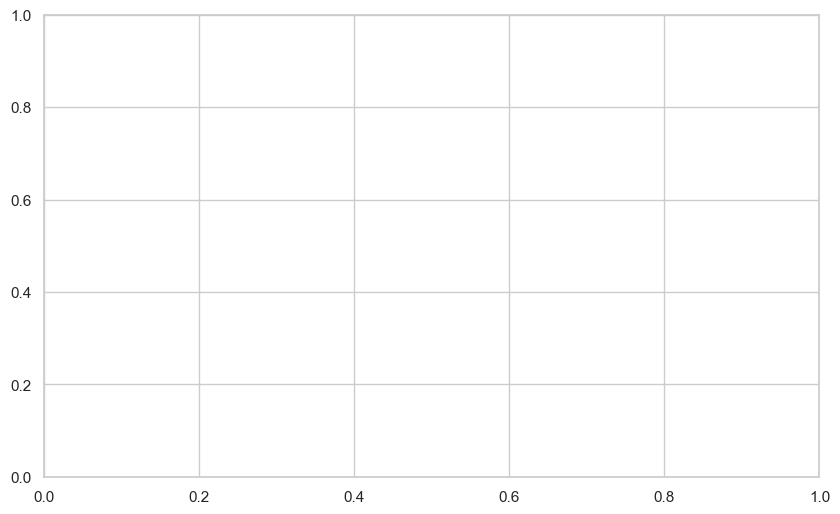

In [58]:
#11. Visualizado
# seaborn mejora estética de gráficos
import seaborn as sns

# Estilo más limpio (tipo paper)
sns.set(style="whitegrid")


# ------------------------------------------------------------
# 1. Impacto de K en el rendimiento (GRÁFICO PRINCIPAL)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="K",
    y="ROC-AUC",
    hue="Model",
    marker="o"
)

plt.title("Impacto del número de genes (K) en el rendimiento (ROC-AUC)")
plt.xlabel("Número de genes seleccionados (K)")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Comparación de modelos para K alto (ej: K = 1000)
# ------------------------------------------------------------
# Elegimos el K más alto (puedes cambiarlo si quieres)
K_SELECTED = 1000

df_k = results_df[results_df["K"] == K_SELECTED]

plt.figure(figsize=(10, 6))

df_k.set_index("Model")[["ROC-AUC", "F1", "Accuracy"]].plot(kind="bar")

plt.title(f"Comparación de modelos (K = {K_SELECTED})")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. (Opcional) Evolución de F1-score
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df,
    x="K",
    y="F1",
    hue="Model",
    marker="o"
)

plt.title("Impacto de K en F1-score")
plt.xlabel("Número de genes seleccionados (K)")
plt.ylabel("F1-score")

plt.tight_layout()
plt.show()

In [ ]:
# FIN DEL EXPERIMENTO
# Tiempo total
total_end = time.time()
print(f"\nTiempo total: {total_end - total_start:.2f} s")

# Sonido al terminar (Windows)
import winsound
winsound.Beep(1000, 500)

print("\n=== FIN DEL EXPERIMENTO ===")